# Big Data Lab Work

### Installing Dependencies

In [206]:
# # %pip install --force-reinstall "ipykernel==6.28.0"
# %pip uninstall -y ipykernel
# %pip install "ipykernel==6.28.0"
import ipykernel
print(ipykernel.__version__)
import polars as pl

6.28.0


Jojie works best with older version of polars. Latest version causes kernel to crash on import

In [207]:
# # %pip install polars
# !python -m pip uninstall -y polars polars-runtime-32 polars-runtime-64 polars-lts-cpu
# !python -m pip install "polars==0.20.31"

### Viewing Datasets through Bash/Terminal

In [208]:
!ls -lh /mnt/data/public/polymarket/

total 568K
-rwxrwxr-x+ 1 root root 9.5K Mar 27 16:52 README.md
-rwxrwxr-x+ 1 root root 523K Mar 27 16:52 banner.png
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 features
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 labels
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 orderbook
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 snapshots


In [209]:
!nvidia-smi

No devices were found


In [210]:
!ls -lh /mnt/data/public/polymarket/features

total 31M
-rwxrwxr-x+ 1 root root 31M Mar 27 16:52 ml_features_1m_v2.parquet


In [211]:
ls -lh /mnt/data/public/polymarket/labels

total 48M
-rwxrwxr-x+ 1 root root 15M Mar 27 16:52 market_targets.parquet*
-rwxrwxr-x+ 1 root root 33M Mar 27 16:52 trades.parquet*


In [212]:
ls -lh /mnt/data/public/polymarket/orderbook | head -5

total 35G
-rwxrwxr-x+ 1 root root 2.0G Mar 27 16:53 orderbook_2026-03-06.parquet*
-rwxrwxr-x+ 1 root root 2.1G Mar 27 16:55 orderbook_2026-03-07.parquet*
-rwxrwxr-x+ 1 root root 2.2G Mar 27 16:58 orderbook_2026-03-08.parquet*
-rwxrwxr-x+ 1 root root 1.3G Mar 27 17:00 orderbook_2026-03-09.parquet*


In [213]:
ls -lh /mnt/data/public/polymarket/snapshots | head -5

total 3.9G
-rwxrwxr-x+ 1 root root 302M Mar 27 17:32 snapshots_2026-03-06.parquet*
-rwxrwxr-x+ 1 root root 224M Mar 27 17:32 snapshots_2026-03-07.parquet*
-rwxrwxr-x+ 1 root root 228M Mar 27 17:32 snapshots_2026-03-08.parquet*
-rwxrwxr-x+ 1 root root  81M Mar 27 17:33 snapshots_2026-03-09.parquet*


In [214]:
!du -sch /mnt/data/public/polymarket/*

12K	/mnt/data/public/polymarket/README.md
524K	/mnt/data/public/polymarket/banner.png
31M	/mnt/data/public/polymarket/features
48M	/mnt/data/public/polymarket/labels
35G	/mnt/data/public/polymarket/orderbook
3.9G	/mnt/data/public/polymarket/snapshots
39G	total


In [215]:
# path = "/mnt/data/public/polymarket/labels/market_targets.parquet"
path = "/mnt/data/public/polymarket/features/ml_features_1m_v2.parquet"

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(100).collect().to_pandas()
# df_market.collect().describe()

,market_id,minute_bar,close_mid,mean_spread,close_spread,bar_volatility,total_volume,buy_volume,sell_volume,trade_count,order_flow_imbalance,target,return_1m,bid_depth,ask_depth,depth_imbalance
0,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:00:00+00:00,0.2850,0.453750,0.450,0.0050,0.0,0.0,0.0,0,0.0,0,0.017857,287.79,3845.07,-0.860731
1,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:01:00+00:00,0.2850,0.450000,0.450,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,287.79,3845.07,-0.860731
2,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:02:00+00:00,0.2900,0.443333,0.440,0.0050,0.0,0.0,0.0,0,0.0,0,0.017544,287.79,3845.07,-0.860731
3,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:03:00+00:00,0.2900,0.440000,0.440,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,287.79,3845.07,-0.860731
4,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:04:00+00:00,0.2900,0.440000,0.440,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,366.80,8838.88,-0.920310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 03:04:00+00:00,0.4850,0.970000,0.970,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,10.80,186.75,-0.890661
96,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 03:05:00+00:00,0.4850,0.970000,0.970,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,10.80,186.75,-0.890661
97,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 03:21:00+00:00,0.0050,0.010000,0.010,0.0000,0.0,0.0,0.0,0,0.0,0,-0.989691,10.80,186.75,-0.890661
98,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 03:22:00+00:00,0.0050,0.010000,0.010,0.0000,0.0,0.0,0.0,0,0.0,0,0.000000,10.80,186.75,-0.890661


#### Reading Labels

In [216]:
# path = "/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet"
path = "/mnt/data/public/polymarket/labels/market_targets.parquet"
path = "/mnt/data/public/polymarket/labels/trades.parquet"

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(100).collect().to_pandas()
# df_market.collect().describe()

,condition_id,side,outcome,price,size,timestamp,asset
0,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,No,0.790000,37.974682,1773535485,5475751391326417034909210895395778447254138036...
1,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.850000,5.000000,1773554079,8945166516904290673857818127174024824733820142...
2,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.850000,1.176466,1773569429,8945166516904290673857818127174024824733820142...
3,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.820000,1.219511,1773594139,8945166516904290673857818127174024824733820142...
4,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,No,0.540179,20.363634,1773636999,5475751391326417034909210895395778447254138036...
...,...,...,...,...,...,...,...
95,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,Yes,0.117000,9.400000,1773467031,6203533918419524766542070754953293312455087712...
96,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,Yes,0.120000,5.000000,1773467977,6203533918419524766542070754953293312455087712...
97,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,No,0.964000,5.000000,1773469173,8052752854383609253127056003138630746422603315...
98,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,No,0.963000,5.000000,1773469915,8052752854383609253127056003138630746422603315...


#### Reading OrderBook

In [217]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("View Polymarket Orderbook Parquet")
    .getOrCreate()
)

path = "/mnt/data/public/polymarket/orderbook/orderbook_2026-03-06.parquet"

df = spark.read.parquet(path)

# Show schema
df.printSchema()

# Show first 20 rows without truncating columns
df.show(20, truncate=False)

# Optional: see column names
print(df.columns)

# Optional: count rows, can be slow for 2GB+
print("Row count:", df.count())

root
 |-- timestamp_received: long (nullable = true)
 |-- timestamp_created_at: long (nullable = true)
 |-- market_id: string (nullable = true)
 |-- best_bid: float (nullable = true)
 |-- best_ask: float (nullable = true)
 |-- change_price: float (nullable = true)
 |-- change_size: float (nullable = true)
 |-- change_side: string (nullable = true)
 |-- token_id: string (nullable = true)
 |-- spread: float (nullable = true)
 |-- mid_price: float (nullable = true)

+------------------+--------------------+------------------------------------------------------------------+--------+--------+------------+-----------+-----------+-----------------------------------------------------------------------------+------------+---------+
|timestamp_received|timestamp_created_at|market_id                                                         |best_bid|best_ask|change_price|change_size|change_side|token_id                                                                     |spread      |mid_price|
+-

In [218]:
df.limit(10).toPandas()

,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
0,1772755441639,1772755441679,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,1000.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
1,1772755573852,1772755578267,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.133,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
2,1772755574100,1772755578472,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.133,40.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
3,1772755577386,1772755579670,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.043,256.700012,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
4,1772755658205,1772755658227,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,900.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
5,1772755964391,1772755964470,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.154,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
6,1772756105891,1772756105922,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,1000.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
7,1772756146031,1772756146049,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.699,200.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
8,1772756200595,1772756200608,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.043,250.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
9,1772756240758,1772756240799,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.699,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011


In [219]:
# df.groupBy("update_type") \
#   .count() \
#   .orderBy(col("count").desc()) \
#   .show(truncate=False)

#### Reading Snapshots

In [220]:
path = "/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet"

df2 = spark.read.parquet(path)
df2.limit(10).toPandas()

,timestamp_received,timestamp_created_at,market_id,update_type,data
0,1772755479569,1772755479636,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
1,1772757306842,1772757306884,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
2,1772758741660,1772758741701,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
3,1772758749082,1772758749140,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
4,1772757678461,1772757678492,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
5,1772757825635,1772757825916,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
6,1772758000770,1772758000792,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
7,1772758045967,1772758045980,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
8,1772758055224,1772758055235,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
9,1772756288585,1772756288645,0x004230fb1f54a139d50ba2041e062a01461c931a6725...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."


# Big Data Mining

### Loading Data
Set Subsample Size and Number of Days of Data to Calculate Here

In [221]:
# %pip install polars

To Speed Up Our Run we will be using Polars Dataframe for our Data Mining and Wrangling   
Note: For Jojie, a lower version needs to be installed  
!python -m pip install "polars==0.20.31"  
More about Polars Here https://pola.rs/
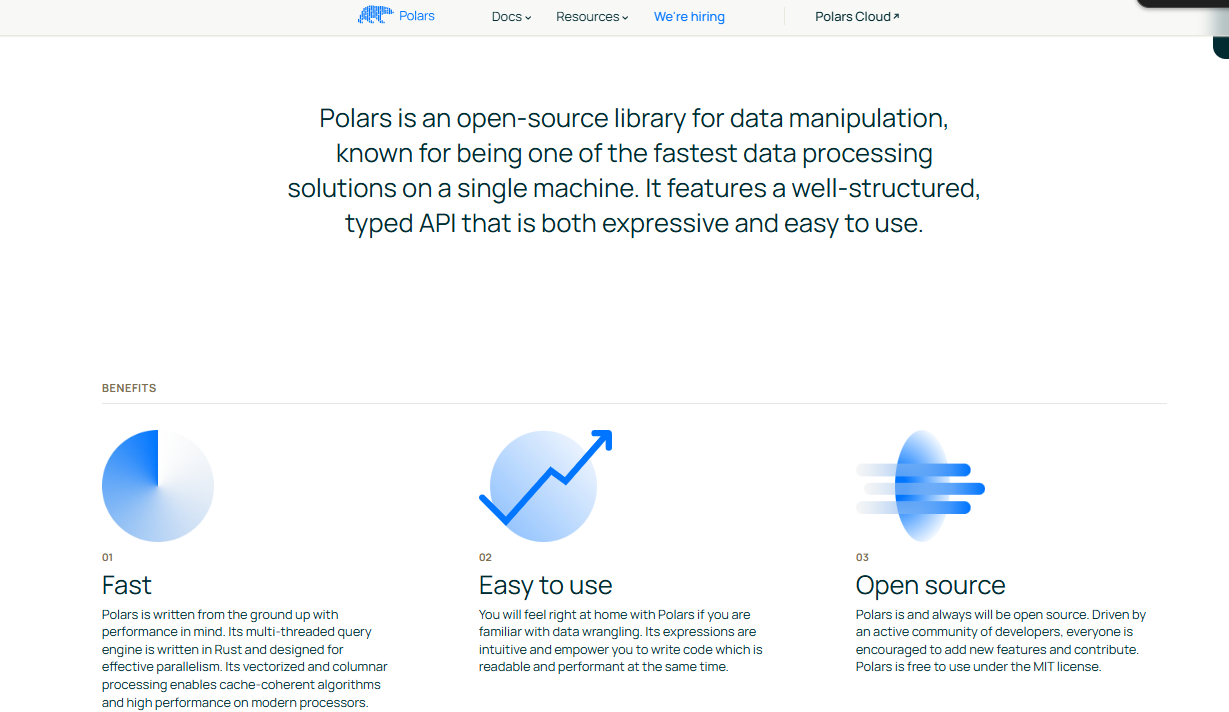

In [222]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, MaxNLocator


Select what files to open and run

In [223]:
import os
import re
from datetime import datetime

# Reuse existing spark session
# spark = SparkSession.builder...getOrCreate()

DATA_DIR = "/mnt/data/public/polymarket"
ob_dir = f"{DATA_DIR}/orderbook"
snap_dir = f"{DATA_DIR}/snapshots"

# -----------------------------
# Date filter options
# -----------------------------
# Option A: inclusive range
START_DATE = "2026-03-06"   # set None to disable
END_DATE   = "2026-03-06"   # set None to disable

# Option B: explicit date set (takes priority if not None)
INCLUDE_DATES = None
# Example:
# INCLUDE_DATES = {"2026-03-01", "2026-03-03", "2026-03-06"}

date_pattern = re.compile(r"(\d{4}-\d{2}-\d{2})")

def extract_date(fname: str):
    m = date_pattern.search(fname)
    return m.group(1) if m else None

def keep_file_by_date(fname: str):
    d = extract_date(fname)
    if d is None:
        return False

    if INCLUDE_DATES is not None:
        return d in INCLUDE_DATES

    if START_DATE is None and END_DATE is None:
        return True

    dt = datetime.strptime(d, "%Y-%m-%d").date()
    if START_DATE is not None and dt < datetime.strptime(START_DATE, "%Y-%m-%d").date():
        return False
    if END_DATE is not None and dt > datetime.strptime(END_DATE, "%Y-%m-%d").date():
        return False
    return True

# Orderbook files filtered by date
ob_files_all = sorted([f for f in os.listdir(ob_dir) if f.endswith(".parquet")])
ob_files = [f for f in ob_files_all if keep_file_by_date(f)]
assert ob_files, "No orderbook parquet files matched your date filter."

print(f"Selected orderbook files: {len(ob_files)}")
for f in ob_files[:10]:
    print(" ", f)
if len(ob_files) > 10:
    print(" ...")

# Build full paths and read with Spark
ob_paths = [f"{ob_dir}/{f}" for f in ob_files]

Selected orderbook files: 1
  orderbook_2026-03-06.parquet


## Exploring Market Targets  
Note: Documents All Unique Market ids

Loading Data

In [224]:
# path = "/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet"
path = "/mnt/data/public/polymarket/labels/market_targets.parquet"

# # Spark Dataframe Version
# df3 = spark.read.parquet(path)
# df3.limit(100).toPandas()

# # Polar Dataframe Version
# df3 = pl.scan_parquet(path)
# df3.limit(10).collect().to_pandas()

# # Spark Dataframe Version
# df3 = spark.read.parquet(path)
# df3.limit(100).toPandas()

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(10).collect().to_pandas()
df_market.collect().describe()

statistic,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
str,str,str,str,str,f64,str,f64,f64,str,str,f64
"""count""","""123895""","""123895""","""123895""","""123895""",123895.0,"""123895""",123895.0,123895.0,"""123895""","""123895""",23146.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0,"""0""","""0""",100749.0
"""mean""",null,null,null,null,0.788143,null,41404.280168,3403.080497,null,null,0.257885
"""std""",null,null,null,null,null,null,997890.575147,54499.005838,null,null,0.43748
"""min""","""0x00000977017fa72fb6b1908ae694…",""" Eileen Gu citizenship revoked…","""""","""""",0.0,"""""",0.0,0.0,"""100000492764540534240318503884…","""100003518014986691537784890523…",0.0
"""25%""",null,null,null,null,null,null,0.0,0.0,null,null,0.0
"""50%""",null,null,null,null,null,null,0.0,0.0,null,null,0.0
"""75%""",null,null,null,null,null,null,0.0,0.0,null,null,1.0
"""max""","""0xffffee23a70d3172cafb93d9df5d…","""Ōita Trinita vs. Renofa Yamagu…","""""","""2029-01-20T00:00:00Z""",1.0,"""resolved""",1.7297e8,5.5462e6,"""999998020512762733701478486959…","""999993562505286457300544147609…",1.0


In [225]:
# from pathlib import Path
# import shutil

# # source file (choose one)
# # src = Path("/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet")
# src = Path("/mnt/data/public/polymarket/labels/market_targets.parquet")

# # destination in current working directory
# dst = Path.cwd() / src.name

# shutil.copy2(src, dst)
# print(f"Copied to: {dst.resolve()}")

### Filtering Market Targets

Filtering Condition_id/Market_id into Higher Liquidity and Volume Markets  
Removing Dead Markets

Rows before:  123,895
Rows after:   2,633
Rows removed: 121,262 (97.87%)


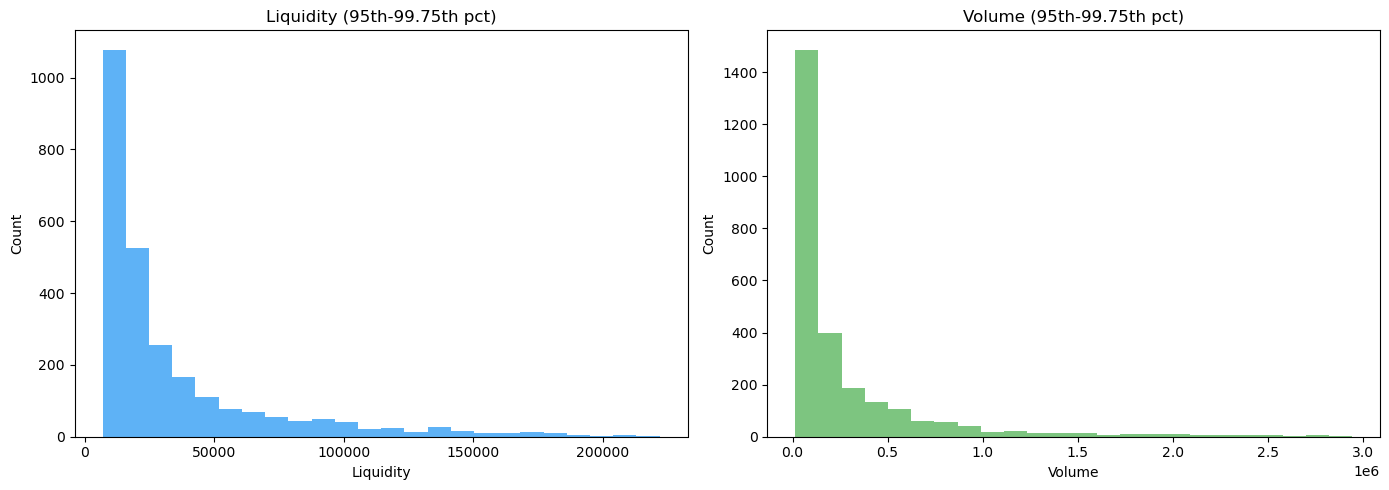

In [226]:
import numpy as np
import matplotlib.pyplot as plt

market_df = df_market.collect() if isinstance(df_market, pl.LazyFrame) else df_market

# keep middle 98% (1st to 99th percentile)
p_low, p_high = 95, 99.75
# p_low, p_high = 0, 100

liq_all = market_df["liquidity"].drop_nulls().to_numpy()
vol_all = market_df["volume"].drop_nulls().to_numpy()

liq_min, liq_max = np.percentile(liq_all, [p_low, p_high])
vol_min, vol_max = np.percentile(vol_all, [p_low, p_high])

before_rows = market_df.height

filtered = market_df.filter(
    pl.col("liquidity").is_between(liq_min, liq_max, closed="both") &
    pl.col("volume").is_between(vol_min, vol_max, closed="both")
)

after_rows = filtered.height
removed_rows = before_rows - after_rows
removed_pct = (removed_rows / before_rows * 100) if before_rows else 0.0

print(f"Rows before:  {before_rows:,}")
print(f"Rows after:   {after_rows:,}")
print(f"Rows removed: {removed_rows:,} ({removed_pct:.2f}%)")


liq = filtered["liquidity"].to_numpy()
vol = filtered["volume"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liq, bins=24, color="#42A5F5", alpha=0.85, edgecolor="none")
axes[0].set_title(f"Liquidity ({p_low}th-{p_high}th pct)")
axes[0].set_xlabel("Liquidity")
axes[0].set_ylabel("Count")

axes[1].hist(vol, bins=24, color="#66BB6A", alpha=0.85, edgecolor="none")
axes[1].set_title(f"Volume ({p_low}th-{p_high}th pct)")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


**Filtering Observation**  
A Large Majority of the Market Have Little to No Liquidity and Volume. We can classify these as dead markets or markets with little activity and most likely give no meaningful information

Using 1 day only considering markets with 97.5% to 99.75% of the liquidity and Volume Value
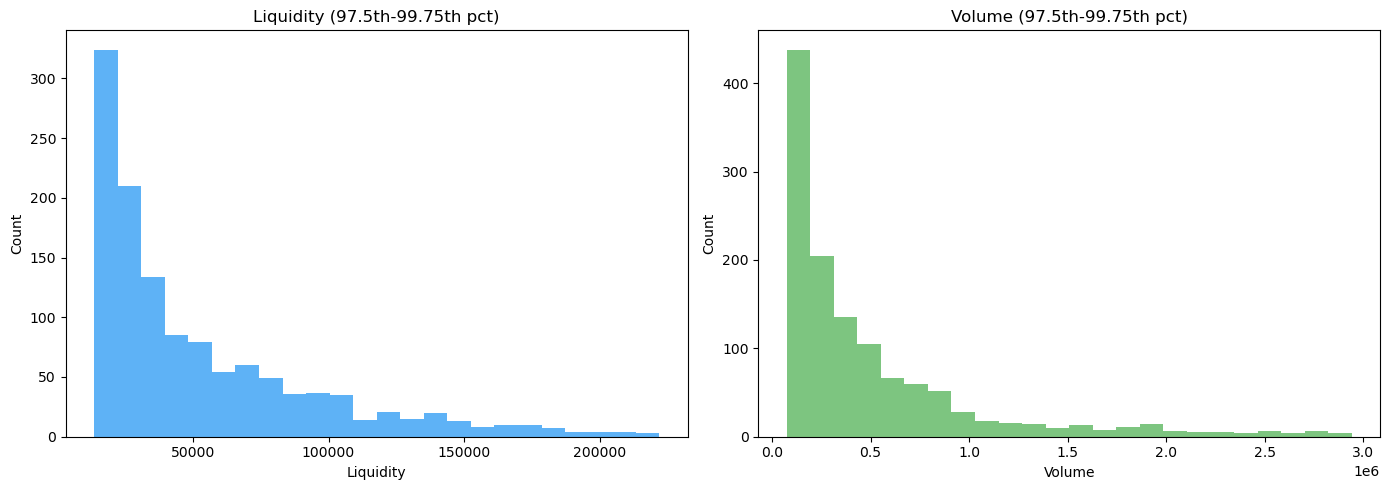

Using 1 day file all data
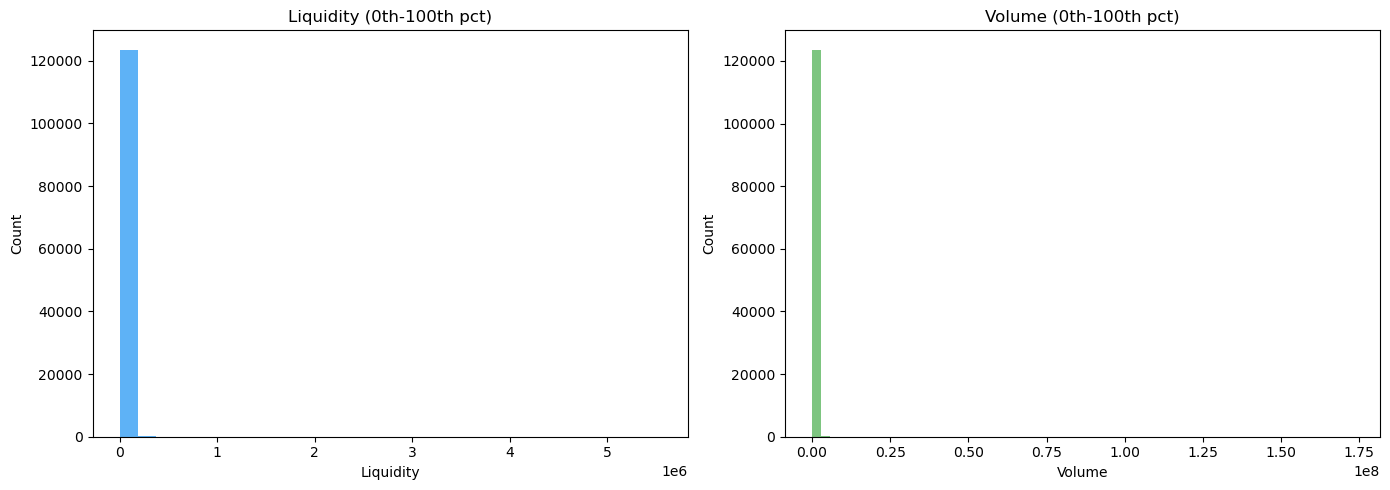

## Exploring Market Targets: Topic Bucketing
- Polymarket Questions involve a wide range topic categories from politics, to entertainment, to memes etc. In order to observe how the market behaves across different topics, we will attempt to classify each question using NLP.
- Here we attempt to categorize the markets using hugging face transformer with facebook model facebook/bart-large-mnli" for a zero-shot classification
- this helps to study the behavior of the markets by category/topic and if underlying behaviors emerge from those observations
- we set the categories and the transformer then finds the probabilities for each topic to match each classifier
- topic discovery was conducted in a seperate notebook using NMF Topic Modelling Approach
- NOTE: RUN ONLY ON JOJIE CPU. Transformer labeling is about half a minute per row

View Here to know more about Transformers for Zero-Shot Classification https://huggingface.co/docs/transformers/v4.25.1/index
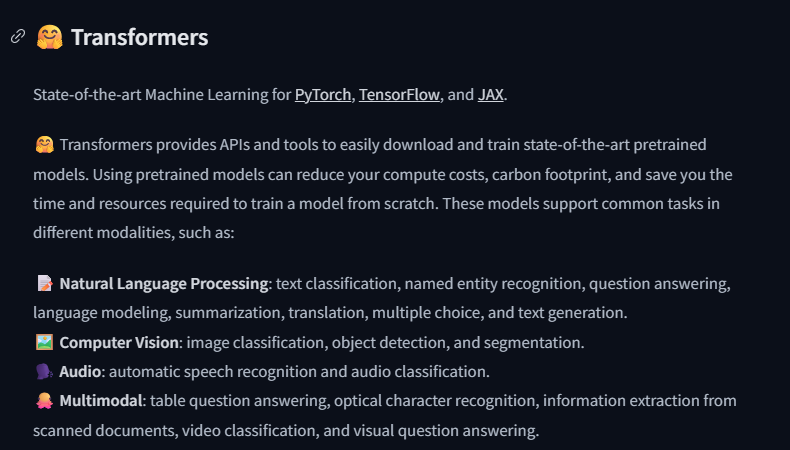

In [227]:
# Polar Dataframe Version
filtered.head(5).to_pandas()

,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
0,0xb48621f7eba07b0a3eeabc6afb09ae42490239903997...,BitBoy convicted?,,2026-03-31T12:00:00Z,False,,2.266330e+05,9631.43077,7546712961590831958303147464265888547913563043...,3842963720267267286970642336860752782302644680...,NaN
1,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,,2026-07-31T12:00:00Z,False,,1.403228e+06,100309.56630,8501497159083948713316135768103773293754490207...,2527312495175492857904889758552137141356236738...,NaN
2,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,,2026-07-31T12:00:00Z,False,,6.751036e+05,32729.52530,9802249026969240999812649612759703249033407008...,5383155306188300653073987728410593891972140877...,NaN
3,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,,2026-07-31T12:00:00Z,False,,7.094616e+05,29544.93060,8827504006008477337655718797221526751304984864...,9437620581602295554297963554227993296735991576...,NaN
4,0x84f8b70331323c2fba97d7ceaa9a35fb645a0770d0db...,Trump out as President before GTA VI?,,2026-07-31T12:00:00Z,False,,5.564197e+05,106972.10780,1089997232078979418764529355570116040679173891...,6453357980929752557903360996363493950101333285...,NaN


In [228]:
# !pip install transformers torch

In [229]:
# import polars as pl
# import pandas as pd
# from transformers import pipeline

Classify Polymarket   
- Uses Hugging Face Transformer to Classifty Quesions based on Embeddings to get a probabily for the best matched candidate labels for each Question.
- Zero-shot Classification
- 3 Labels are selected for each question and ranked based on their probabilities/likelihoods of being correct.

In [230]:
# # 1) Load question lookup
# # labels = pl.read_parquet("slt3a/Lab 1/data/market_targets.parquet")
# labels = pl.read_parquet("data/market_targets.parquet")
# labels_lu = (
#     labels
#     .select(["condition_id", "question"])
#     .unique(subset=["condition_id"])
# )

# # 2) Attach question text to your filtered table
# filtered_with_q = (
#     filtered
#     .join(labels_lu, on="condition_id", how="left")
#     .filter(pl.col("question").is_not_null())
# )

# # 3) Convert to pandas for easy iteration
# pdf = filtered_with_q.select([
#     "condition_id", "question", "volume", "liquidity", "target"
# ]).to_pandas()

# # Optional: dedupe repeated questions per condition_id before classifying
# # pdf_unique = pdf.drop_duplicates(subset=["condition_id"]).copy() # RUNS ENTIRE DATASET
# # pdf_unique = pdf.drop_duplicates(subset=["condition_id"]).head(500).copy() # TEST RUN on smaller dataset
# pdf_unique = (
#     pdf
#     .drop_duplicates(subset=["condition_id"])
#     .iloc[2100:] # SET LIMIT HERE
#     .copy()
# )
# # 4) Zero-shot classifier
# classifier = pipeline(
#     "zero-shot-classification",
#     model="facebook/bart-large-mnli",
#     device=0 # 0 to use GPU and -1 for CPU. GPU only works in Jojie
# )

# candidate_labels = ["politics", "entertainment","sports", "crypto", "economy", "world events", "culture", "science", "finance", "others"]

# # # 5) Classify (top label + score)
# # def classify_question(q):
# #     r = classifier(q, candidate_labels=candidate_labels, multi_label=False)
# #     return pd.Series({
# #         "pred_label": r["labels"][0],
# #         "pred_score": r["scores"][0]
# #     })
# # 5) Classify (top 3 labels + scores)
# def classify_question(q):
#     r = classifier(str(q), candidate_labels=candidate_labels, multi_label=False)
#     return pd.Series({
#         "top1_label": r["labels"][0], "top1_score": r["scores"][0],
#         "top2_label": r["labels"][1], "top2_score": r["scores"][1],
#         "top3_label": r["labels"][2], "top3_score": r["scores"][2],
#     })

# top3 = pdf_unique["question"].apply(classify_question)
# pdf_unique = pd.concat([pdf_unique, top3], axis=1)

# out = pdf.merge(
#     pdf_unique[[
#         "condition_id",
#         "top1_label", "top1_score",
#         "top2_label", "top2_score",
#         "top3_label", "top3_score"
#     ]],
#     on="condition_id",
#     how="left"
# )

# # out.head(10)
# # out.write_parquet("slt3a/Lab 1/data/market_targets_classified.parquet")
# # pl.from_pandas(out).write_parquet("slt3a/Lab 1/data/market_targets_classified.parquet")

In [231]:
# Computing Time it Takes to Complete
# print(len(filtered))
rows = (len(filtered)-1500)/1.89
print(rows) # Rows considered
(rows)/(10/46.6)/60/60 # hours to complete run

599.4708994708996


0.77598177542622

Save Extracted Files

In [232]:
# pl.from_pandas(out).write_parquet("data/market_targets_classified.parquet")
# out.head(10)

Combine and Load Classified Data

In [233]:
# # Combine Data Script
# import polars as pl
# from pathlib import Path

# # Update this path if your files are elsewhere
# base = Path("slt3a/Lab 1/data")

# files = [
#     base / "market_targets_classified_500.parquet",
#     base / "market_targets_classified_500_1500.parquet",
#     base / "market_targets_classified_1500_2100.parquet",
#     base / "market_targets_classified_2100_.parquet",
# ]

# # Read and combine
# dfs = [pl.read_parquet(f) for f in files]
# combined = pl.concat(dfs, how="vertical_relaxed")

# # Optional: remove duplicates if splits might overlap
# # combined = combined.unique()

# # Save merged output
# out_path = base / "market_targets_classified_all.parquet"
# combined.write_parquet(out_path)

# print(f"Rows: {combined.height:,}")
# print(f"Cols: {combined.width}")
# print(f"Saved: {out_path.resolve()}")




### Exploring Classified Market Questions

Load Data

In [234]:
# Load Data
path = "slt3a/Lab 1/data/market_targets_classified_all.parquet"
# Polar Dataframe Version
df_market_class = pl.scan_parquet(path)
df_market_class.limit(10).collect().to_pandas()

,condition_id,question,volume,liquidity,target,top1_label,top1_score,top2_label,top2_score,top3_label,top3_score
0,0xb48621f7eba07b0a3eeabc6afb09ae42490239903997...,BitBoy convicted?,2.266330e+05,9631.43077,NaN,crypto,0.299586,culture,0.160860,world events,0.105243
1,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,1.403228e+06,100309.56630,NaN,world events,0.374225,entertainment,0.192539,politics,0.159172
2,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,6.751036e+05,32729.52530,NaN,entertainment,0.426875,culture,0.282794,others,0.128860
3,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,7.094616e+05,29544.93060,NaN,culture,0.404774,entertainment,0.387945,others,0.077784
4,0x84f8b70331323c2fba97d7ceaa9a35fb645a0770d0db...,Trump out as President before GTA VI?,5.564197e+05,106972.10780,NaN,politics,0.467959,entertainment,0.197605,world events,0.108710
5,0x7b49b9bacb5f435bc10f3b100ff59e2fdd346f7f92a9...,Will China invades Taiwan before GTA VI?,1.511593e+06,134101.15460,NaN,world events,0.386171,politics,0.189475,entertainment,0.129622
6,0xd8c3fff562711af557abca5e7367dbb892b1d79419b0...,Will Italy qualify for the 2026 FIFA World Cup?,3.004808e+05,12624.08450,NaN,sports,0.449746,world events,0.289835,others,0.110545
7,0xbd9068da0f92022747bdad7a7d522c2f8bec81f0eb61...,Will Poland qualify for the 2026 FIFA World Cup?,4.806090e+05,7738.76690,NaN,world events,0.334703,sports,0.315193,others,0.153806
8,0xfef0954af0d43ea46c1ac246ac009dbcd0f76d36fd93...,Will Ukraine qualify for the 2026 FIFA World Cup?,1.746828e+05,140037.36685,NaN,sports,0.419361,world events,0.315538,others,0.105165
9,0xf7b5491e70b477d451afe7d9c1fde4bf1a927e69ff28...,Will the Carolina Hurricanes win the 2026 NHL ...,2.193104e+05,103915.72540,NaN,sports,0.916923,others,0.028116,culture,0.011863


In [235]:
df_market_class.collect().describe()

statistic,condition_id,question,volume,liquidity,target,top1_label,top1_score,top2_label,top2_score,top3_label,top3_score
str,str,str,f64,f64,f64,str,f64,str,f64,str,f64
"""count""","""10532""","""10532""",10532.0,10532.0,0.0,"""2633""",2633.0,"""2633""",2633.0,"""2633""",2633.0
"""null_count""","""0""","""0""",0.0,0.0,10532.0,"""7899""",7899.0,"""7899""",7899.0,"""7899""",7899.0
"""mean""",null,null,276960.15032,34051.005563,null,null,0.516957,null,0.135976,null,0.089407
"""std""",null,null,439598.182561,36117.039379,null,null,0.223391,null,0.069291,null,0.048549
"""min""","""0x00000977017fa72fb6b1908ae694…",""" Eileen Gu citizenship revoked…",13645.776548,6959.13906,null,"""crypto""",0.142234,"""crypto""",0.012954,"""crypto""",0.007519
"""25%""",null,null,37963.441646,11801.31767,null,null,0.310546,null,0.079049,null,0.048767
"""50%""",null,null,102429.796418,19702.11979,null,null,0.484013,null,0.128664,null,0.082573
"""75%""",null,null,309840.409527,39634.19862,null,null,0.723474,null,0.185903,null,0.128673
"""max""","""0xffdbbf2c3b9aa808abbcb35beb2b…","""o1 FDV above $100M one day aft…",2.9412e6,221815.12089,null,"""world events""",0.945649,"""world events""",0.393691,"""world events""",0.260405


Visualizing Composition of High liquidity and volume markets

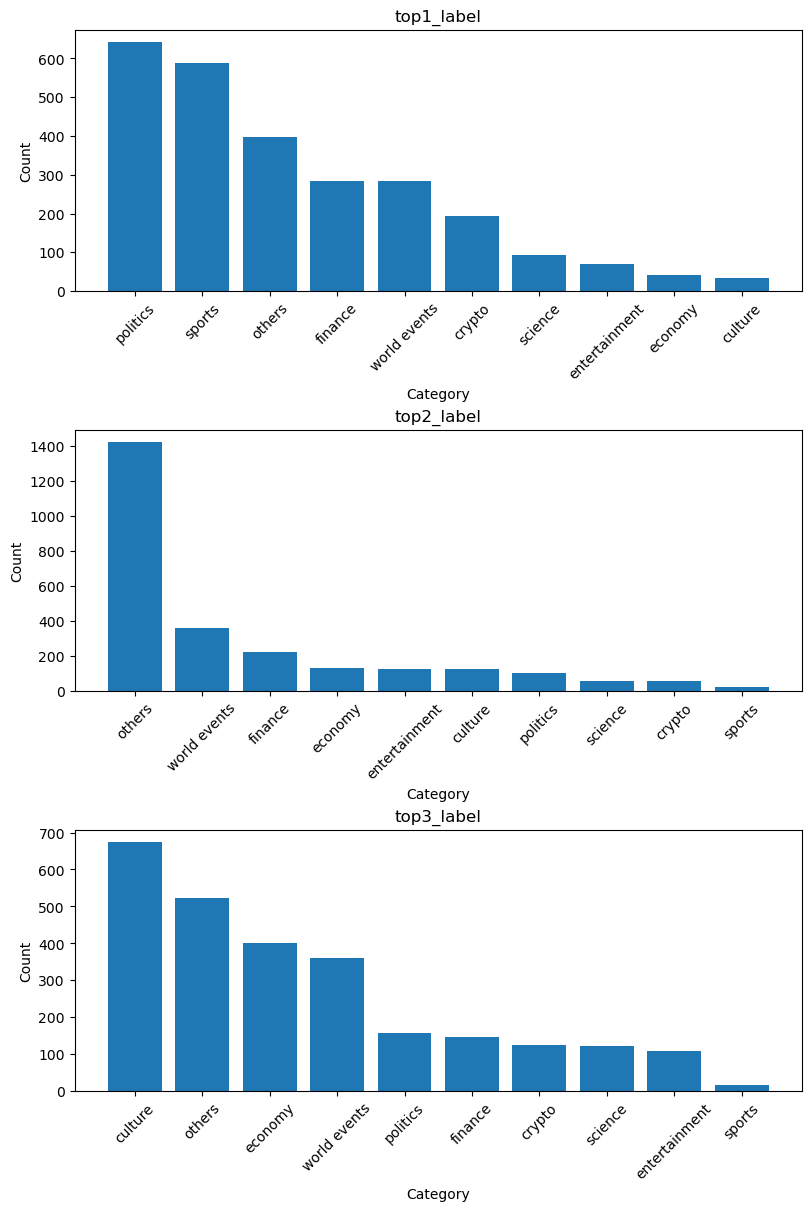

In [236]:
import polars as pl
import matplotlib.pyplot as plt

# Materialize once
df = df_market_class.collect()

# Pick 3 label columns automatically (contains "label" and is string/categorical)
label_cols = [
    c for c, dt in zip(df.columns, df.dtypes)
    if "label" in c.lower() and dt in (pl.Utf8, pl.Categorical, pl.Enum)
]

if len(label_cols) < 3:
    raise ValueError(f"Found only {len(label_cols)} label columns: {label_cols}")

# Choose top 3 by non-null count
top3_cols = sorted(label_cols, key=lambda c: df[c].drop_nulls().len(), reverse=True)[:3]

# Plot
fig, axes = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

for ax, col in zip(axes, top3_cols):
    vc = (
        df.select(pl.col(col).drop_nulls().value_counts())
        .unnest(col)
        .sort("count", descending=True)
        .head(15)  # top 15 categories for readability
    )

    labels = vc[col].to_list()
    counts = vc["count"].to_list()

    ax.bar(labels, counts)
    ax.set_title(col)
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.show()


**Observations**  
After running the transformer classifiers, we see politics and sports being the top contents of the polymarket topics questions. The other following topics include finance, world events, and crypto.

The 2nd and 3rd rank labels do show higher "other" classification instead of more meaningful labels. Manually Observing the rows and data labels, the top 1 labels should be enough for our market category analysis.

## Exploring OrderBook Ticks

### Filtered OrderBooks

Filtering Orderbooks to Markets the have meaningful volume and liquidity over dead markets

Rows before:  123,895
Rows after:   2,633
Rows removed: 121,262 (97.87%)


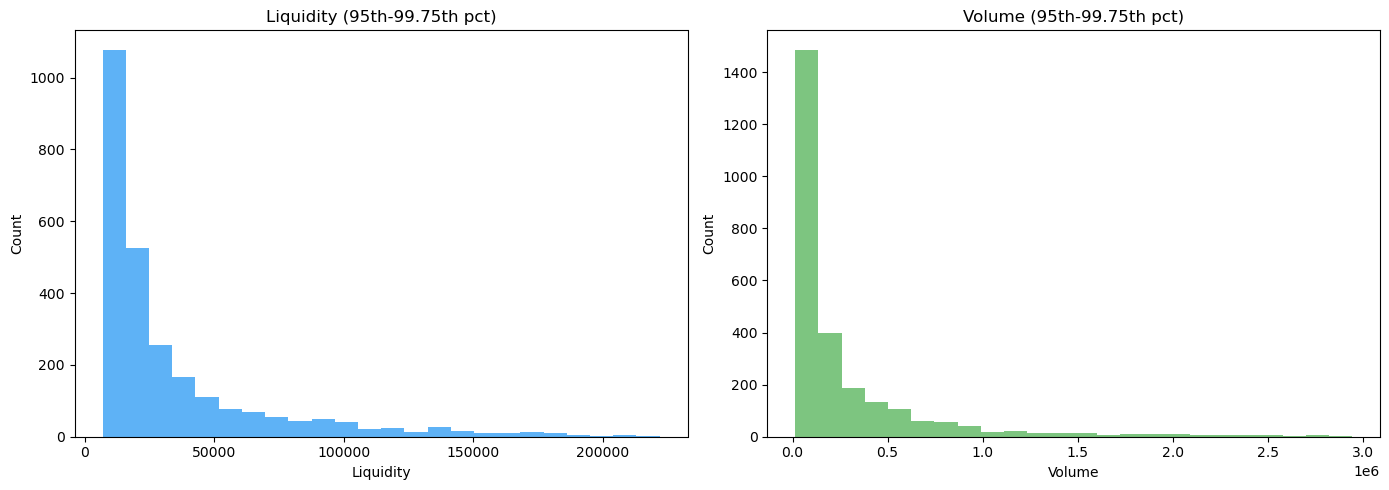

In [238]:
import numpy as np
import matplotlib.pyplot as plt

market_df = df_market.collect() if isinstance(df_market, pl.LazyFrame) else df_market

# keep middle 98% (1st to 99th percentile)
p_low, p_high = 95, 99.75
# p_low, p_high = 0, 100

liq_all = market_df["liquidity"].drop_nulls().to_numpy()
vol_all = market_df["volume"].drop_nulls().to_numpy()

liq_min, liq_max = np.percentile(liq_all, [p_low, p_high])
vol_min, vol_max = np.percentile(vol_all, [p_low, p_high])

before_rows = market_df.height

filtered = market_df.filter(
    pl.col("liquidity").is_between(liq_min, liq_max, closed="both") &
    pl.col("volume").is_between(vol_min, vol_max, closed="both")
)

after_rows = filtered.height
removed_rows = before_rows - after_rows
removed_pct = (removed_rows / before_rows * 100) if before_rows else 0.0

print(f"Rows before:  {before_rows:,}")
print(f"Rows after:   {after_rows:,}")
print(f"Rows removed: {removed_rows:,} ({removed_pct:.2f}%)")


liq = filtered["liquidity"].to_numpy()
vol = filtered["volume"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liq, bins=24, color="#42A5F5", alpha=0.85, edgecolor="none")
axes[0].set_title(f"Liquidity ({p_low}th-{p_high}th pct)")
axes[0].set_xlabel("Liquidity")
axes[0].set_ylabel("Count")

axes[1].hist(vol, bins=24, color="#66BB6A", alpha=0.85, edgecolor="none")
axes[1].set_title(f"Volume ({p_low}th-{p_high}th pct)")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [237]:
import polars as pl
import numpy as np

market_df = df_market.collect() if isinstance(df_market, pl.LazyFrame) else df_market

p_low, p_high = 95, 99.75
liq_all = market_df["liquidity"].drop_nulls().to_numpy()
vol_all = market_df["volume"].drop_nulls().to_numpy()
liq_min, liq_max = np.percentile(liq_all, [p_low, p_high])
vol_min, vol_max = np.percentile(vol_all, [p_low, p_high])

filtered = market_df.filter(
    pl.col("liquidity").is_between(liq_min, liq_max, closed="both") &
    pl.col("volume").is_between(vol_min, vol_max, closed="both")
)

# Keep mapping from condition_id -> question
market_map = (
    filtered
    .select(
        pl.col("condition_id").cast(pl.Utf8).alias("market_id"),
        pl.col("question")
    )
    .unique(subset=["market_id"])   # avoids duplicates per market_id
)

market_ids = market_map["market_id"].to_list()

sample_file = ob_files[-2] if len(ob_files) > 1 else ob_files[0]
ob_lf = pl.scan_parquet(f"{DATA_DIR}/orderbook/{sample_file}").with_columns(
    pl.col("market_id").cast(pl.Utf8)
)

chunk_size = 20_000
parts = []

for i in range(0, len(market_ids), chunk_size):
    ids_chunk = market_ids[i:i + chunk_size]
    map_chunk = market_map.filter(pl.col("market_id").is_in(ids_chunk))

    part = (
        ob_lf
        .join(map_chunk.lazy(), on="market_id", how="inner")  # includes question
        .with_row_index("row_idx")
        .filter(pl.col("row_idx") % 500 == 0)
        .drop("row_idx")
        .collect(engine="streaming")
    )
    if part.height > 0:
        parts.append(part)

sample = pl.concat(parts, how="vertical") if parts else pl.DataFrame()

print(f"Sample: {sample.height:,} rows, {sample.width} columns")
if sample.height:
    print(f"Unique markets in sample: {sample['market_id'].n_unique():,}")

sample.select(["market_id", "question","spread"]).head(5).to_pandas()


Sample: 51,290 rows, 12 columns
Unique markets in sample: 2,108


,market_id,question,spread
0,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,Will Zelenskyy and Putin meet next in Saudi Ar...,0.004
1,0x00a9dd3c3174468e2cee6ffa418dbf9b7e95c09788c2...,Will the Milwaukee Bucks win the NBA Eastern C...,0.001
2,0x00da1f8d0b1f8fac5a6d1cb44dc84f6bc1af7d552e45...,Bank of Japan increases interest rates by 50+ ...,0.001
3,0x00da1f8d0b1f8fac5a6d1cb44dc84f6bc1af7d552e45...,Bank of Japan increases interest rates by 50+ ...,0.001
4,0x00da1f8d0b1f8fac5a6d1cb44dc84f6bc1af7d552e45...,Bank of Japan increases interest rates by 50+ ...,0.001


Median Spread Metric  
Calculates the median spread for each market sorted descending together with descending ticks.

In [149]:
# Polar Dataframe Version. Filtered to High Liquidity and Volume Markets
filtered.head(5).to_pandas()

,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
0,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,,2026-07-31T12:00:00Z,False,,1.403228e+06,100309.5663,8501497159083948713316135768103773293754490207...,2527312495175492857904889758552137141356236738...,NaN
1,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,,2026-07-31T12:00:00Z,False,,6.751036e+05,32729.5253,9802249026969240999812649612759703249033407008...,5383155306188300653073987728410593891972140877...,NaN
2,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,,2026-07-31T12:00:00Z,False,,7.094616e+05,29544.9306,8827504006008477337655718797221526751304984864...,9437620581602295554297963554227993296735991576...,NaN
3,0x84f8b70331323c2fba97d7ceaa9a35fb645a0770d0db...,Trump out as President before GTA VI?,,2026-07-31T12:00:00Z,False,,5.564197e+05,106972.1078,1089997232078979418764529355570116040679173891...,6453357980929752557903360996363493950101333285...,NaN
4,0x7b49b9bacb5f435bc10f3b100ff59e2fdd346f7f92a9...,Will China invades Taiwan before GTA VI?,,2026-07-31T12:00:00Z,False,,1.511593e+06,134101.1546,2169513887321137545105556677010768232549420672...,1751642757638338275636846765620625820649001595...,NaN


In [160]:
labels = pl.read_parquet("/mnt/data/public/polymarket/labels/market_targets.parquet")

labels_lu = (
    labels
    .select(["condition_id", "question"])
    .unique(subset=["condition_id"])
    .with_columns(pl.col("condition_id").cast(pl.Utf8))
)

median_spread_table = (
    sample
    .with_columns(pl.col("market_id").cast(pl.Utf8))
    .filter(pl.col("spread") > 0)
    .group_by("market_id")
    .agg([
        pl.col("spread").median().alias("median_spread"),
        pl.len().alias("ticks"),
    ])
    .join(labels_lu, left_on="market_id", right_on="condition_id", how="left")
    .select(["market_id", "question", "median_spread", "ticks"])
    .sort(
        by=["median_spread", "ticks"],
        descending=[False, True],  # median_spread asc, ticks desc
    )
)

median_spread_table.head(30).to_pandas()

,market_id,question,median_spread,ticks
0,0xaf4c3ba4d1b1568d4309bba0874cb7eec1e5b40a648f...,"Will Anthropic not IPO by June 30, 2026?",0.001,31
1,0x79bc9eae1f5ce8f3f58648f45e7ff7cf182a8314e2d1...,Will Ukraine win Eurovision 2026?,0.001,43
2,0xd4adc3e7d85d7bd90d11e6680fc775376ef568e88ee3...,Foreign intervention in Gaza by March 31?,0.001,21
3,0xdd6df6bc49de64cf38b2059cea20d00b86ef0c01b4c1...,Will the Jacksonville Jaguars win the 2027 NFL...,0.001,15
4,0xda9e24f8b6b8f71f02a79fe9d27348f6cbf2ff670cbe...,Will Charlie Kirk win the Nobel Peace Prize in...,0.001,13
5,0x8e29cb5c6b8d6b8d259114ffca2796fb378d1e0575f8...,Will the Denver Broncos win the 2027 NFL leagu...,0.001,12
6,0x69a24b337ef9c44ef2cda8ddc69bf32cba38dec05846...,Will the Detroit Lions win the 2027 NFL league...,0.001,10
7,0x201f51d2d892c41c5bfa6568a0a2f93ab2ea426e87dd...,"Will Ethereum reach $10,000 by December 31, 2026?",0.001,5
8,0xcc5494faf5ceca60a77a46db255b8c8e30b1bcc7d94d...,Based FDV above $500M one day after launch?,0.001,1
9,0x508c917d0ee4a7a5535e825c3f85ee47d27fc1e72f88...,Will the New York Jets win the 2027 NFL league...,0.001,28


**Observation**  
Mean Spread or the difference between the highest bid and the lowest ask can help indicate liquid markets. Here we see a combination of Politics, Sports, and War Related Events tend to have higher liquidity by mean spread.

Re-assigns Dataset to Unfiltered Data

In [152]:
# sample_file = ob_files[-2] if len(ob_files) > 1 else ob_files[0]
# sample = (
#     pl.scan_parquet(f"{DATA_DIR}/orderbook/{sample_file}")
#     .with_row_index("row_idx")
#     .filter(pl.col("row_idx") % 500 == 0)
#     .drop("row_idx")
#     .collect()
# )

# print(f"Sample: {sample.height:,} rows, {sample.width} columns")
# print(f"Columns: {sample.columns}")
# print(f"\nUnique markets in sample: {sample['market_id'].n_unique():,}")
# print(f"Time range: {sample['timestamp_received'].min()} → {sample['timestamp_received'].max()}")
# print()
# # print(sample.head(5))
# sample.head(5).to_pandas()

Statistics Check:  
For Reference the entire dataset should be  
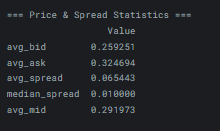

In [153]:
# Basic statistics on the core price columns
print("=== Price & Spread Statistics ===")
print(sample.select([
    pl.col("best_bid").mean().alias("avg_bid"),
    pl.col("best_ask").mean().alias("avg_ask"),
    pl.col("spread").mean().alias("avg_spread"),
    pl.col("spread").median().alias("median_spread"),
    pl.col("mid_price").mean().alias("avg_mid"),
]).to_pandas().T.rename(columns={0: "Value"}))

=== Price & Spread Statistics ===
                  Value
avg_bid        0.160885
avg_ask        0.173469
avg_spread     0.012584
median_spread  0.007000
avg_mid        0.167177


In [154]:
sample.describe()

statistic,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price,question
str,f64,f64,str,f64,f64,f64,f64,str,str,f64,f64,str
"""count""",29257.0,29257.0,"""29257""",29257.0,29257.0,29257.0,29257.0,"""29257""","""29257""",29257.0,29257.0,"""29257"""
"""null_count""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0""",0.0,0.0,"""0"""
"""mean""",1.7728e12,1.7728e12,null,0.160885,0.173469,0.300673,30726.917969,null,null,0.012584,0.167177,null
"""std""",2.4765e7,2.4765e7,null,0.232488,0.237501,0.292705,395397.34375,null,null,0.020406,0.234787,null
"""min""",1.7728e12,1.7728e12,"""0x006e3bc30b325c9cd4e4a35e3373…",0.0,0.001,0.001,0.0,"""BUY""","""100089942478247842028749951289…",0.001,0.0005,""" Iran agrees to end enrichment…"
"""25%""",1.7728e12,1.7728e12,null,0.01,0.015,0.062,5.0,null,null,0.002,0.0125,null
"""50%""",1.7728e12,1.7728e12,null,0.047,0.059,0.18,60.0,null,null,0.007,0.054,null
"""75%""",1.7728e12,1.7728e12,null,0.19,0.21,0.51,612.98999,null,null,0.015,0.1995,null
"""max""",1.7728e12,1.7728e12,"""0xffdbbf2c3b9aa808abbcb35beb2b…",0.993,0.994,0.999,1.1100525e7,"""SELL""","""999514682180077996994307140148…",0.427,0.9935,"""Zhang Youxia sentenced to pris…"


Spread Distribution

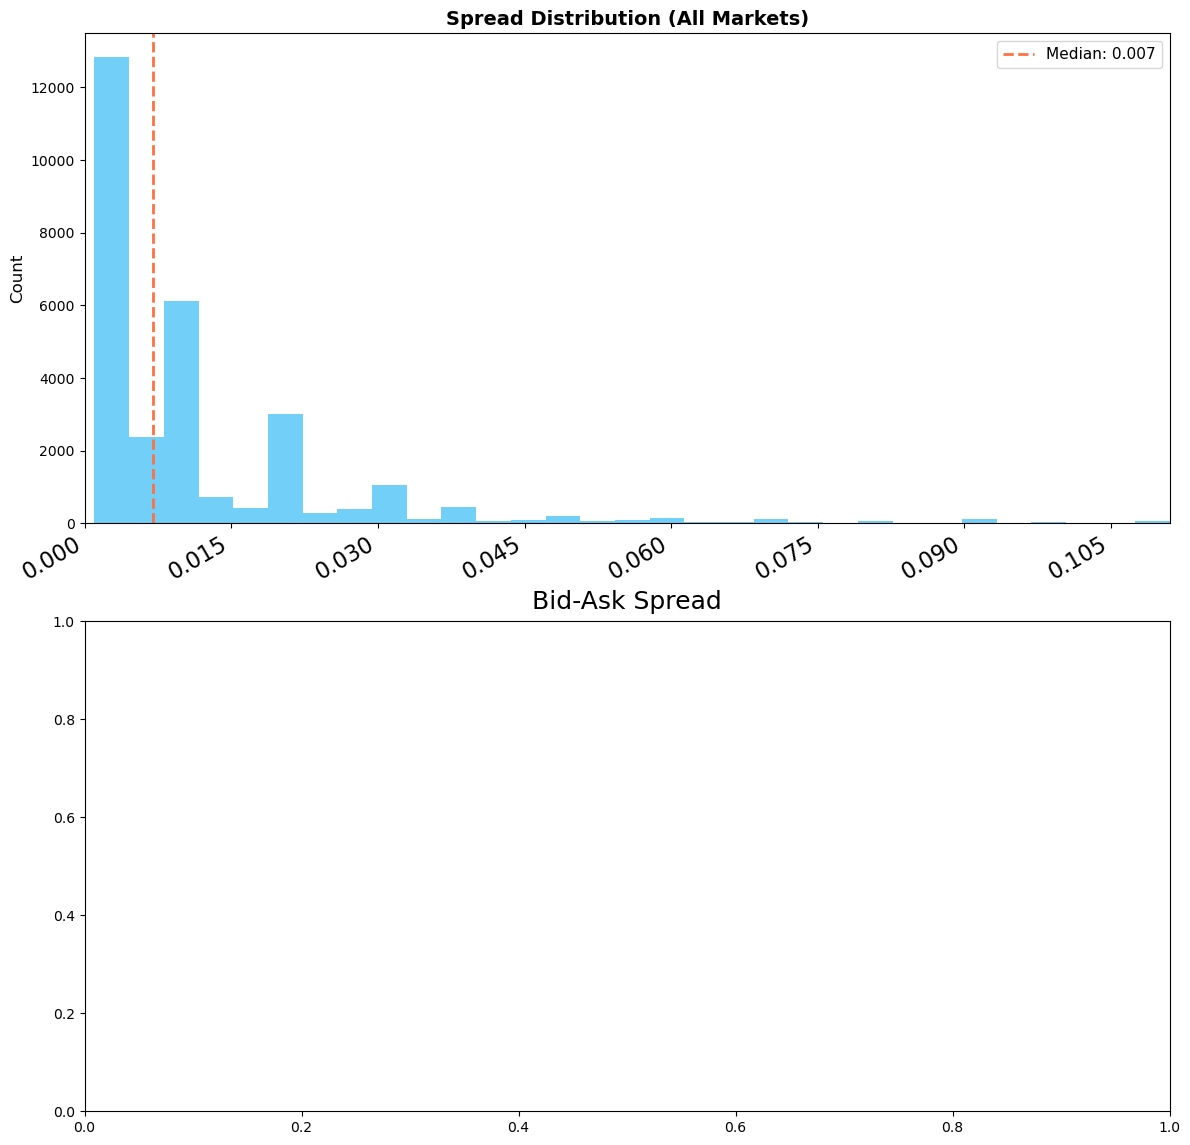

In [164]:
spreads = sample.filter(pl.col("spread") > 0)["spread"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Histogram
axes[0].hist(spreads, bins=120, color="#4FC3F7", edgecolor="none", alpha=0.8)
axes[0].axvline(np.median(spreads), color="#FF7043", linestyle="--", linewidth=2, label=f"Median: {np.median(spreads):.3f}")
axes[0].set_xlabel("Bid-Ask Spread", fontsize=18)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Spread Distribution (All Markets)", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, min(0.3, np.percentile(spreads, 99)))
axes[0].tick_params(axis="x", labelsize=16)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].xaxis.set_major_locator(MultipleLocator(0.015))   # change step as needed

# # Top markets by tightest spreads
# market_spreads = (
#     sample.group_by("market_id")
#     .agg([
#         pl.col("spread").median().alias("median_spread"),
#         pl.len().alias("ticks"),
#     ])
#     .sort("median_spread")
#     .head(15)
# )
# ms = market_spreads.to_pandas()
# colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ms)))
# axes[1].barh(range(len(ms)), ms["median_spread"], color=colors)
# axes[1].set_yticks(range(len(ms)))
# axes[1].set_yticklabels([mid[:12] + "..." for mid in ms["market_id"]], fontsize=15)
# axes[1].set_xlabel("Median Spread", fontsize=12)
# axes[1].set_title("Tightest Markets (Most Liquid)", fontsize=12, fontweight="bold")
# axes[1].invert_yaxis()

# plt.tight_layout()
# plt.show()

In [158]:
labels = pl.read_parquet("/mnt/data/public/polymarket/labels/market_targets.parquet")

labels_lu = (
    labels
    .select(["condition_id", "question"])
    .unique(subset=["condition_id"])
)

tightest_table = (
    sample
    .filter(pl.col("spread") > 0)
    .group_by("market_id")
    .agg([
        pl.col("spread").median().alias("median_spread"),
        pl.len().alias("ticks"),
    ])
    .sort("median_spread")
    .head(30)
    .join(labels_lu, left_on="market_id", right_on="condition_id", how="left")
    .select(["market_id", "question", "median_spread", "ticks"])
)

tightest_table.to_pandas()


,market_id,question,median_spread,ticks
0,0xaf4c3ba4d1b1568d4309bba0874cb7eec1e5b40a648f...,"Will Anthropic not IPO by June 30, 2026?",0.001,31
1,0xd4adc3e7d85d7bd90d11e6680fc775376ef568e88ee3...,Foreign intervention in Gaza by March 31?,0.001,21
2,0x79bc9eae1f5ce8f3f58648f45e7ff7cf182a8314e2d1...,Will Ukraine win Eurovision 2026?,0.001,43
3,0xda9e24f8b6b8f71f02a79fe9d27348f6cbf2ff670cbe...,Will Charlie Kirk win the Nobel Peace Prize in...,0.001,13
4,0x69a24b337ef9c44ef2cda8ddc69bf32cba38dec05846...,Will the Detroit Lions win the 2027 NFL league...,0.001,10
5,0xdd6df6bc49de64cf38b2059cea20d00b86ef0c01b4c1...,Will the Jacksonville Jaguars win the 2027 NFL...,0.001,15
6,0xcc5494faf5ceca60a77a46db255b8c8e30b1bcc7d94d...,Based FDV above $500M one day after launch?,0.001,1
7,0x8e29cb5c6b8d6b8d259114ffca2796fb378d1e0575f8...,Will the Denver Broncos win the 2027 NFL leagu...,0.001,12
8,0x201f51d2d892c41c5bfa6568a0a2f93ab2ea426e87dd...,"Will Ethereum reach $10,000 by December 31, 2026?",0.001,5
9,0xda6293438c50b71777cfa237c0e359e0586e9b5255c2...,Will Sergio Garcia win the 2026 Masters tourna...,0.001,26


Observing Intraday Pattern  
How does the market change within a day?

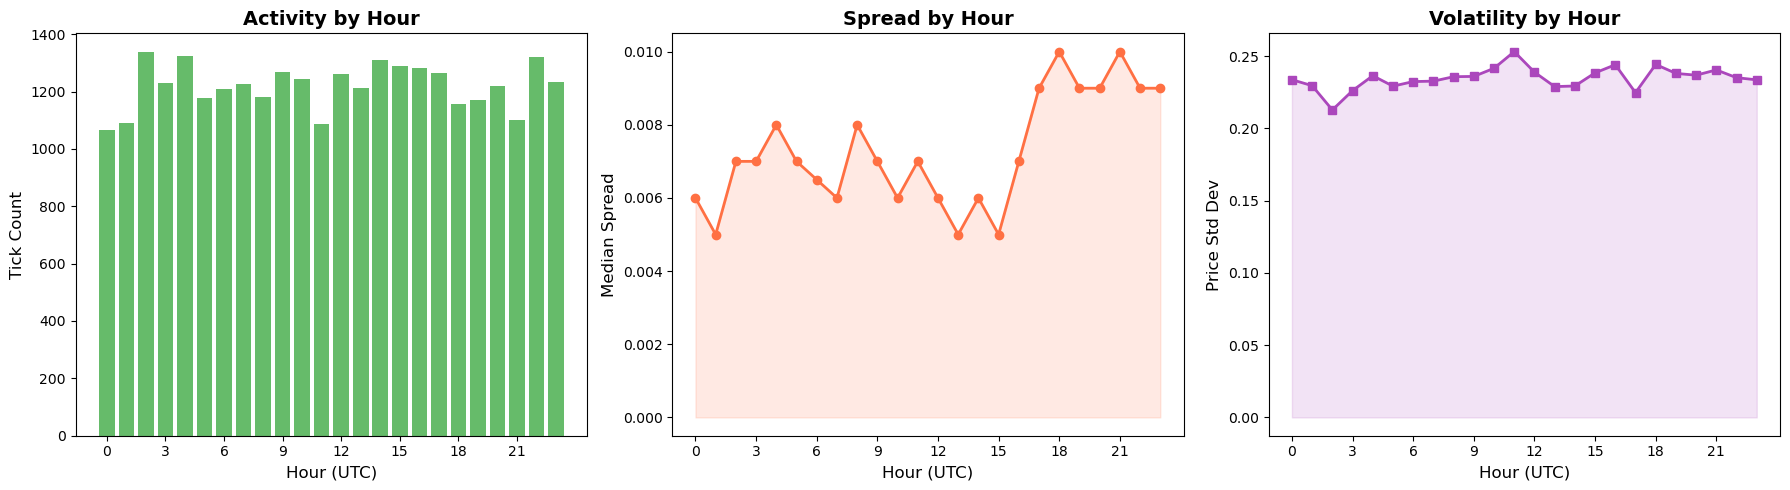

In [161]:
# Add hour-of-day column
hourly = (
    sample
    .with_columns(
        pl.from_epoch("timestamp_received", time_unit="ms")  # change if needed
        .dt.hour()
        .alias("hour")
    )
    .group_by("hour")
    .agg([
        pl.len().alias("tick_count"),
        pl.col("spread").median().alias("median_spread"),
        pl.col("mid_price").std().alias("price_volatility"),
    ])
    .sort("hour")
    .to_pandas()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tick volume by hour
axes[0].bar(hourly["hour"], hourly["tick_count"], color="#66BB6A", edgecolor="none")
axes[0].set_xlabel("Hour (UTC)", fontsize=12)
axes[0].set_ylabel("Tick Count", fontsize=12)
axes[0].set_title("Activity by Hour", fontsize=14, fontweight="bold")
axes[0].set_xticks(range(0, 24, 3))

# Spread by hour
axes[1].plot(hourly["hour"], hourly["median_spread"], color="#FF7043", linewidth=2, marker="o")
axes[1].fill_between(hourly["hour"], hourly["median_spread"], alpha=0.15, color="#FF7043")
axes[1].set_xlabel("Hour (UTC)", fontsize=12)
axes[1].set_ylabel("Median Spread", fontsize=12)
axes[1].set_title("Spread by Hour", fontsize=14, fontweight="bold")
axes[1].set_xticks(range(0, 24, 3))

# Volatility by hour
axes[2].plot(hourly["hour"], hourly["price_volatility"], color="#AB47BC", linewidth=2, marker="s")
axes[2].fill_between(hourly["hour"], hourly["price_volatility"], alpha=0.15, color="#AB47BC")
axes[2].set_xlabel("Hour (UTC)", fontsize=12)
axes[2].set_ylabel("Price Std Dev", fontsize=12)
axes[2].set_title("Volatility by Hour", fontsize=14, fontweight="bold")
axes[2].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

# TimeSeries Analysis

# Market Manipulation Methodology